# Mini project 3

This notebook simulates **1,000 cases for 10 bonds**, converts default times to quarterly cash flows, and sums the collateral available each quarter. Cases are sorted from worst to best by the number of defaults within five years: case 1 has the most defaults, and case 1,000 has the fewest. Change `SCENARIO_ID` to inspect any ranked case.

**Conventions:** Dollar amounts are in USD; times are in years. Each bond pays a $150,000 quarterly coupon. On default, it pays recovery of 40% of face value ($4 million) once, at the end of the quarter containing default. It pays no coupon in that quarter and nothing afterward. A default exactly on a payment date takes precedence over that payment. There is no accrued coupon. The document specifies LGD but does not specify precise recovery timing, so these are explicit modeling assumptions.

**Correlation requirement:** Every pair of uncensored default times has a target population Pearson correlation of **0.20**. We calibrate the correlation between normal scores, construct their equicorrelation matrix, and use its Cholesky factor to generate correlated normal draws. This latent correlation is calibrated to meet the target after the transformation to default times. The 1,000-case sample correlations will fluctuate around the population target; sorting rows by default count does not change those correlations.

In [1]:
import numpy as np
import pandas as pd
from scipy.special import ndtr, log_ndtr, roots_hermitenorm
from scipy.optimize import brentq
from IPython.display import display

N_SCENARIOS = 1_000
N_BONDS = 10
MATURITY_YEARS = 5
PAYMENTS_PER_YEAR = 4
FACE_VALUE = 10_000_000.0
ANNUAL_COUPON_RATE = 0.06
ANNUAL_DEFAULT_PROBABILITY = 0.04
LGD = 0.60
TARGET_DEFAULT_TIME_CORRELATION = 0.20
SEED = 6103
tranches = pd.DataFrame({
    "initial_notional_usd": [20_000_000.0, 10_000_000.0],
    "annual_coupon": [0.02, 0.04],
}, index=["A", "B"])

DT = 1 / PAYMENTS_PER_YEAR
N_QUARTERS = MATURITY_YEARS * PAYMENTS_PER_YEAR
payment_times = np.arange(1, N_QUARTERS + 1) * DT
quarter_labels = [f"Q{q}" for q in range(1, N_QUARTERS + 1)]
bond_labels = [f"Bond {b}" for b in range(1, N_BONDS + 1)]
scenario_ids = pd.Index(range(1, N_SCENARIOS + 1), name="Case")
QUARTERLY_COUPON = FACE_VALUE * ANNUAL_COUPON_RATE * DT
RECOVERY = FACE_VALUE * (1 - LGD)

display(pd.Series({
    "Scenarios": N_SCENARIOS, "Bonds": N_BONDS,
    "Quarters": N_QUARTERS, "Face value per bond ($)": FACE_VALUE,
    "Quarterly coupon per bond ($)": QUARTERLY_COUPON,
    "Recovery per default ($)": RECOVERY,
}, name="Model inputs").to_frame())
display(tranches)

,Model inputs
Scenarios,1000.0
Bonds,10.0
Quarters,20.0
Face value per bond ($),10000000.0
Quarterly coupon per bond ($),150000.0
Recovery per default ($),4000000.0


,initial_notional_usd,annual_coupon
A,20000000.0,0.02
B,10000000.0,0.04


## 1. Convert annual default probability to a hazard rate

A **hazard rate** measures how quickly default can occur, given that the bond has not already defaulted. It describes default risk continuously through time.

It differs slightly from an annual default probability:

- **Annual default probability of 4%:** a surviving bond has a 4% chance of defaulting over the next full year.
- **Hazard rate:** the instantaneous rate of default among bonds that have survived so far. It is a rate per year, not itself a one-year probability.

With a constant hazard rate $\lambda$, survival through time $t$ is $S(t)=e^{-\lambda t}$, so

$$P(\text{default within }t\text{ years})=1-e^{-\lambda t}.$$

To make the one-year default probability equal to 4%, we solve:

$$0.04=1-e^{-\lambda}
\quad\Longrightarrow\quad
\lambda=-\ln(0.96)=0.0408219945\text{ per year}.$$

The notebook uses a **hazard rate of about 4.0822% per year**, distinct from the 4% one-year probability. This lets us generate default times anywhere along the timeline while preserving the required annual default probability.

The conditional quarterly default probability is $1-e^{-\lambda/4}$, and the five-year cumulative default probability is $1-e^{-5\lambda}$. 

In [2]:
hazard_rate = -np.log1p(-ANNUAL_DEFAULT_PROBABILITY)
quarterly_default_probability = -np.expm1(-hazard_rate * DT)
five_year_default_probability = -np.expm1(-hazard_rate * MATURITY_YEARS)
assert np.isclose(-np.expm1(-hazard_rate), ANNUAL_DEFAULT_PROBABILITY)
print(f"Annual hazard rate: {hazard_rate:.10f} ({hazard_rate:.6%})")
print(f"Conditional quarterly default probability: {quarterly_default_probability:.6%}")
print(f"Five-year cumulative default probability: {five_year_default_probability:.6%}")

Annual hazard rate: 0.0408219945 (4.082199%)
Conditional quarterly default probability: 1.015360%
Five-year cumulative default probability: 18.462730%


## 2. Calibrate correlation and generate default times

The target applies to **default times**, so we find the normal-score correlation $\rho$ that produces a population default-time correlation of 0.20. We build a $10\times10$ equicorrelation matrix $R$, with ones on the diagonal and calibrated $\rho$ elsewhere, then factor it as $R=LL^T$.

For each bond, generate 1,000 independent standard-normal draws. **Moment-match each column** by subtracting its sample mean and dividing by its sample standard deviation (`ddof=1`). Each column then has sample mean 0 and sample standard deviation 1; cross-column sample correlations remain close to, but not necessarily exactly, zero.

For scenario rows, apply the Cholesky factor as $X=ZL^T$, then transform the correlated normals through the standard normal CDF and inverse exponential CDF:

$$U_{s,i}=\Phi(X_{s,i}),\qquad
\tau_{s,i}=F^{-1}(U_{s,i})=-\frac{\ln(1-U_{s,i})}{\lambda}.$$

Cases are sorted from most to fewest defaults within five years. The same seed and settings reproduce the draws, moment-matched normals, default times, and case ordering.

**Correlation calibration.** For each candidate $\rho$, we integrate the distribution of one correlated pair of normal scores to calculate the implied population correlation of their exponential default times. Let $A$ and $B$ be independent standard normals:

$$X_i=A,\qquad X_j=\rho A+\sqrt{1-\rho^2}B.$$

This evaluates a bivariate normal expectation; it does not generate scenarios or replace the 10-dimensional Cholesky simulation.

By symmetry of the standard normal, $-\ln(1-\Phi(X))=-\ln\Phi(-X)$ has the same joint distribution as $g(X)=-\ln\Phi(X)$ when the normal-score correlation is $\rho$. For a standard normal $X$, $g(X)$ is exponential with mean and variance 1. Therefore,

$$\operatorname{Corr}(\tau_i,\tau_j)=E[g(X_i)g(X_j)]-1.$$

Gauss–Hermite quadrature evaluates this expectation, and a root solver finds the $\rho$ for which the population default-time correlation is 0.20. We verify the result at a higher quadrature order. The target applies to full default times, including times beyond five years.

In [3]:
def implied_default_time_correlation(rho, quadrature_order=48):
    """Population correlation of exponential times from correlated normals."""
    if not 0 <= rho <= 1:
        raise ValueError("The normal-score correlation must lie between 0 and 1.")
    nodes, weights = roots_hermitenorm(quadrature_order)
    weights = weights / np.sqrt(2 * np.pi)
    x = nodes[:, None]
    y = rho * x + np.sqrt(1 - rho**2) * nodes[None, :]
    g_x, g_y = -log_ndtr(x), -log_ndtr(y)
    expected_product = np.sum(weights[:, None] * weights[None, :] * g_x * g_y)
    return float(expected_product - 1.0)

if not 0 <= TARGET_DEFAULT_TIME_CORRELATION <= 1:
    raise ValueError("This Gaussian-copula model supports targets from 0 to 1.")
if TARGET_DEFAULT_TIME_CORRELATION in (0, 1):
    LATENT_RHO = float(TARGET_DEFAULT_TIME_CORRELATION)
else:
    LATENT_RHO = brentq(
        lambda rho: implied_default_time_correlation(rho) - TARGET_DEFAULT_TIME_CORRELATION,
        0.0, 1.0, xtol=1e-12,
    )

verified_population_correlation = implied_default_time_correlation(LATENT_RHO, quadrature_order=80)
np.testing.assert_allclose(verified_population_correlation, TARGET_DEFAULT_TIME_CORRELATION,
                           rtol=0, atol=1e-9)
np.testing.assert_allclose(implied_default_time_correlation(0.0, 80), 0.0, rtol=0, atol=1e-9)
np.testing.assert_allclose(implied_default_time_correlation(1.0, 80), 1.0, rtol=0, atol=1e-9)
print(f"Target default-time correlation: {TARGET_DEFAULT_TIME_CORRELATION:.6f}")
print(f"Calibrated normal-score correlation: {LATENT_RHO:.10f}")
print(f"Verified population default-time correlation: {verified_population_correlation:.10f}")
print(f"For comparison, normal-score correlation 0.20 implies default-time correlation "
      f"{implied_default_time_correlation(0.20, 80):.6f}.")

Target default-time correlation: 0.200000
Calibrated normal-score correlation: 0.2332349314
Verified population default-time correlation: 0.2000000000
For comparison, normal-score correlation 0.20 implies default-time correlation 0.170302.


In [4]:
rng = np.random.default_rng(SEED)
normal_correlation = np.full((N_BONDS, N_BONDS), LATENT_RHO)
np.fill_diagonal(normal_correlation, 1.0)
cholesky_factor = np.linalg.cholesky(normal_correlation)
independent_normals = rng.standard_normal((N_SCENARIOS, N_BONDS))
independent_normals = (
    independent_normals - independent_normals.mean(axis=0)
) / independent_normals.std(axis=0, ddof=1)
latent_scores = independent_normals @ cholesky_factor.T
sample_latent_correlation = np.corrcoef(latent_scores, rowvar=False)
uniforms = ndtr(latent_scores)
uniforms = np.clip(uniforms, np.finfo(float).tiny, np.nextafter(1.0, 0.0))
default_times = -np.log1p(-uniforms) / hazard_rate

# Rank cases from most to fewest defaults; stable ties keep seeded simulation order.
unranked_default_counts = (default_times <= MATURITY_YEARS).sum(axis=1)
scenario_order = np.argsort(-unranked_default_counts, kind="stable")
original_case_ids = scenario_order + 1
default_counts = unranked_default_counts[scenario_order]
rank_ids = pd.Index(range(1, N_SCENARIOS + 1), name="Rank")
case_ranking = pd.DataFrame({
    "original_case_id": original_case_ids,
    "defaults_within_5_years": default_counts,
}, index=rank_ids)

independent_normals = independent_normals[scenario_order]
latent_scores = latent_scores[scenario_order]
uniforms = uniforms[scenario_order]
default_times = default_times[scenario_order]
scenario_ids = rank_ids
default_times_df = pd.DataFrame(default_times, index=rank_ids, columns=bond_labels)

assert default_times.shape == (N_SCENARIOS, N_BONDS)
assert np.all(np.isfinite(default_times)) and np.all(default_times > 0)
assert np.allclose(independent_normals.mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(independent_normals.std(axis=0, ddof=1), 1.0, atol=1e-12)
assert case_ranking["defaults_within_5_years"].is_monotonic_decreasing
assert case_ranking["original_case_id"].is_unique
assert case_ranking["original_case_id"].between(1, N_SCENARIOS).all()
assert default_counts[0] == default_counts.max()
assert default_counts[-1] == default_counts.min()
print("Case ranking by defaults within five years (highest-default cases first):")
display(case_ranking.head(10))
print(f"Lowest-default cases (ranks {N_SCENARIOS - 4}-{N_SCENARIOS}):")
display(case_ranking.tail(5))
print("Default times in years, first five ranked cases:")
display(default_times_df.head().round(4))
print(f"Defaults in rank 1 (worst): {default_counts[0]} / {N_BONDS}")
print(f"Defaults in rank {N_SCENARIOS} (best): {default_counts[-1]} / {N_BONDS}")
print(f"Defaults within five years: {default_counts.sum():,} / {default_times.size:,}")
print(f"Average sample latent-normal correlation: "
      f"{sample_latent_correlation[np.triu_indices(N_BONDS, k=1)].mean():.4f} "
      f"(target {LATENT_RHO:.4f})")

Case ranking by defaults within five years (highest-default cases first):


,original_case_id,defaults_within_5_years
Rank,,
1,140,9
2,618,9
3,760,9
4,74,8
5,216,8
6,321,8
7,562,8
8,759,8
9,850,8


Lowest-default cases (ranks 996-1000):


,original_case_id,defaults_within_5_years
Rank,,
996,978,0
997,979,0
998,981,0
999,999,0
1000,1000,0


Default times in years, first five ranked cases:


,Bond 1,Bond 2,Bond 3,Bond 4,Bond 5,Bond 6,Bond 7,Bond 8,Bond 9,Bond 10
Rank,,,,,,,,,,
1,0.1755,0.3260,2.0744,1.5734,3.7078,0.4596,0.0488,4.3922,18.2728,0.7611
2,4.6125,1.4418,1.3127,3.1634,1.4174,0.7072,0.2324,4.0991,14.5942,0.9683
3,0.1603,1.4381,0.1528,0.6211,1.4186,6.8929,1.8563,0.6154,0.2922,3.1394
4,6.4830,2.6528,0.9545,33.4137,1.5111,0.0283,4.4992,3.4479,3.5883,0.4207
5,1.6990,9.9063,2.3841,4.8846,1.4421,0.8256,0.8919,0.9452,9.8587,0.2782


Defaults in rank 1 (worst): 9 / 10
Defaults in rank 1000 (best): 0 / 10
Defaults within five years: 1,857 / 10,000
Average sample latent-normal correlation: 0.2470 (target 0.2332)


## 3. Convert default times to quarterly bond cash flows

For payment date $t_q=q/4$, coupon $C=150{,}000$, face value $F=10{,}000{,}000$, and recovery $R=4{,}000{,}000$,

$$CF_{s,i,q}=C\,\mathbf{1}_{\{\tau_{s,i}>t_q\}}
+R\,\mathbf{1}_{\{t_{q-1}<\tau_{s,i}\leq t_q\}}
+F\,\mathbf{1}_{\{q=20,\ \tau_{s,i}>5\}}.$$

The first term pays coupons while the bond survives. The second pays recovery only in the default quarter. The third repays principal at maturity only for surviving bonds. Recovery is not discounted. The project’s 9% YTM and 1% risk-free rate are for later valuation, not these contractual cash flows.

In [5]:
def bond_cash_flow_components(times):
    """Map positive default times shaped (scenario, bond) to USD arrays.

    Each returned array has shape (scenario, bond, quarter).
    Positive infinity is allowed to represent no default in a test case.
    """
    times = np.asarray(times, dtype=float)
    if times.ndim != 2 or np.isnan(times).any() or np.any(times <= 0):
        raise ValueError("Default times must be a positive 2-D array; +inf is allowed.")
    tau = times[:, :, None]
    alive = tau > payment_times
    defaults_this_quarter = (tau > (payment_times - DT)) & (tau <= payment_times)
    coupons = QUARTERLY_COUPON * alive
    recoveries = RECOVERY * defaults_this_quarter
    principal = np.zeros_like(coupons)
    principal[:, :, -1] = FACE_VALUE * (times > MATURITY_YEARS)
    return coupons, recoveries, principal

coupon_cash_flows, recovery_cash_flows, principal_cash_flows = bond_cash_flow_components(default_times)
bond_cash_flows = coupon_cash_flows + recovery_cash_flows + principal_cash_flows
assert bond_cash_flows.shape == (N_SCENARIOS, N_BONDS, N_QUARTERS)
assert np.all(bond_cash_flows >= 0)
np.testing.assert_allclose(
    recovery_cash_flows.sum(axis=2), RECOVERY * (default_times <= MATURITY_YEARS)
)
assert np.all(bond_cash_flows[default_times[:, :, None] <= (payment_times - DT)] == 0)
print("Bond cash flow array shape:", bond_cash_flows.shape)

Bond cash flow array shape: (1000, 10, 20)


## 4. Sum the 10 bonds and inspect a case

`collateral_cash_flows[rank - 1, q]` is the sum across all bonds for a ranked case and quarter. Ranks are ordered from most to fewest defaults within five years; ties keep their seeded simulation order. Use the rank slider below to inspect any case. The tables show each bond’s default timing and quarterly cash flows, plus aggregate coupons, recoveries, principal, and collateral total. Cash-flow values are in **millions of dollars**.

In [6]:
collateral_cash_flows = bond_cash_flows.sum(axis=1)
collateral_cash_flows_df = pd.DataFrame(
    collateral_cash_flows, index=scenario_ids, columns=quarter_labels
)
assert collateral_cash_flows.shape == (N_SCENARIOS, N_QUARTERS)

import ipywidgets as widgets

def inspect_scenario(rank=1):
    if not isinstance(rank, (int, np.integer)) or not 1 <= rank <= N_SCENARIOS:
        raise ValueError(f"Choose an integer rank from 1 to {N_SCENARIOS}.")
    case_position = rank - 1
    original_case_id = int(original_case_ids[case_position])
    default_quarters = [
        int(np.searchsorted(payment_times, time, side="left") + 1)
        if time <= MATURITY_YEARS else None for time in default_times[case_position]
    ]
    details = pd.DataFrame({
        "Default time (years)": default_times[case_position],
        "Default quarter": pd.array(default_quarters, dtype="Int64"),
        "Survives maturity": default_times[case_position] > MATURITY_YEARS,
    }, index=bond_labels)
    cash = pd.DataFrame(
        bond_cash_flows[case_position].T / 1e6,
        index=quarter_labels,
        columns=bond_labels,
    )
    cash["Coupons"] = coupon_cash_flows[case_position].sum(axis=0) / 1e6
    cash["Recoveries"] = recovery_cash_flows[case_position].sum(axis=0) / 1e6
    cash["Principal"] = principal_cash_flows[case_position].sum(axis=0) / 1e6
    cash["Collateral total"] = collateral_cash_flows[case_position] / 1e6
    print(
        f"Rank {rank} (original case {original_case_id}): "
        f"{default_counts[case_position]} defaults within five years; cash flows in $ millions."
    )
    display(details.round(4))
    display(cash.round(4))

SCENARIO_ID = 1
scenario_viewer = widgets.interactive(
    inspect_scenario,
    rank=widgets.IntSlider(value=SCENARIO_ID, min=1, max=N_SCENARIOS, step=1,
                           description="Rank:", continuous_update=False),
)
display(scenario_viewer)

interactive(children=(IntSlider(value=1, continuous_update=False, description='Rank:', max=1000, min=1), Outpu…

## 5. Tranche waterfall with principal due at maturity

Class A has $20 million initial principal and a 2% annual coupon; Class B has $10 million and a 4% annual coupon. Scheduled coupons are fixed at $100,000 per quarter for each class, calculated on initial principal throughout the five-year term. Full tranche principal is due only at maturity, so the Q20 scheduled payments are $20.1 million for A and $10.1 million for B, including the final coupons.

Each quarter, all collateral cash flows—bond coupons, default recoveries, and surviving-bond principal—form one cash pool. The waterfall pays A up to its scheduled amount, then B up to its scheduled amount, and distributes any remainder to equity (E). Recoveries do not trigger early tranche principal repayments or reduce future coupons; before maturity, recovery cash left after both scheduled coupons is distributed to equity. No cash is retained for later quarters.

Shortfalls are recorded as scheduled payments minus actual payments for A and B, including any unpaid principal at maturity. They do not carry forward or increase later amounts due. The code checks cash conservation, payment limits, and seniority across all 1,000 ranked cases. The rank slider displays quarterly collateral, A, B, and equity payments in USD.

In [7]:
# 1. Build scheduled payments using the notebook's Q1,...,Q20 labels.
class_names = ["A", "B", "E"]
scheduled_tranche_cash_flows = pd.DataFrame(
    0.0, index=quarter_labels, columns=class_names[:2]
)
tranche_quarterly_coupons = {}

for tranche_name in class_names[:2]:
    notional = tranches.loc[tranche_name, "initial_notional_usd"]
    annual_rate = tranches.loc[tranche_name, "annual_coupon"]
    quarterly_payment = notional * annual_rate / PAYMENTS_PER_YEAR

    tranche_quarterly_coupons[tranche_name] = quarterly_payment
    scheduled_tranche_cash_flows[tranche_name] = quarterly_payment

    # Assumption: full tranche principal is due only at maturity.
    scheduled_tranche_cash_flows.loc[
        quarter_labels[-1], tranche_name
    ] += notional


def apply_waterfall(collateral, schedule):
    """Return USD payments shaped (rank, quarter, class): A=0, B=1, E=2."""
    collateral = np.asarray(collateral, dtype=float)
    schedule = np.asarray(schedule, dtype=float)

    if collateral.ndim != 2:
        raise ValueError("Collateral must be a scenario-by-quarter array.")

    number_of_cases, number_of_quarters = collateral.shape
    if schedule.shape != (number_of_quarters, 2):
        raise ValueError(
            "Schedule must have one row per quarter and columns A, B."
        )

    for values in (collateral, schedule):
        if not np.isfinite(values).all() or (values < 0).any():
            raise ValueError("Cash flows must be finite and nonnegative.")

    payments = np.zeros((number_of_cases, number_of_quarters, 3))

    for case_position in range(number_of_cases):
        for quarter_position in range(number_of_quarters):
            cash_available = collateral[case_position, quarter_position]
            a_due = schedule[quarter_position, 0]
            b_due = schedule[quarter_position, 1]

            a_paid = min(cash_available, a_due)
            cash_remaining = cash_available - a_paid
            b_paid = min(cash_remaining, b_due)
            equity_paid = cash_remaining - b_paid

            payments[case_position, quarter_position] = [
                a_paid, b_paid, equity_paid
            ]

    return payments


# 2. Apply to total collateral, already in rank order.
# Coupons, recoveries, and principal are already included in this array.
schedule_values = scheduled_tranche_cash_flows.to_numpy()
tranche_cash_flows = apply_waterfall(
    collateral_cash_flows, schedule_values
)

class_cash_flows = {
    class_name: pd.DataFrame(
        tranche_cash_flows[:, :, class_position],
        index=collateral_cash_flows_df.index,
        columns=collateral_cash_flows_df.columns,
    )
    for class_position, class_name in enumerate(class_names)
}

# 3. Record shortfalls without adding them to later payments due.
# Broadcast the (20, 2) schedule across all 1,000 ranked scenarios.
tranche_shortfalls = (
    schedule_values[None, :, :] - tranche_cash_flows[:, :, :2]
)

# 4. Validate shape, conservation, payment limits, and seniority.
tolerance = 1e-8

assert tranche_cash_flows.shape == (N_SCENARIOS, N_QUARTERS, 3)
assert tranche_shortfalls.shape == (N_SCENARIOS, N_QUARTERS, 2)
assert np.isfinite(tranche_cash_flows).all()
assert (tranche_cash_flows >= 0).all()
assert (tranche_shortfalls >= -tolerance).all()

np.testing.assert_allclose(
    tranche_cash_flows.sum(axis=2),
    collateral_cash_flows,
    rtol=0,
    atol=tolerance,
)

a_unpaid = tranche_shortfalls[:, :, 0] > tolerance
b_unpaid = tranche_shortfalls[:, :, 1] > tolerance
assert np.all(tranche_cash_flows[:, :, 1][a_unpaid] == 0)
assert np.all(
    tranche_cash_flows[:, :, 2][a_unpaid | b_unpaid] == 0
)

print(
    f"Waterfall checks passed for {N_SCENARIOS:,} ranked cases "
    f"x {N_QUARTERS} quarters."
)
for class_position, class_name in enumerate(class_names[:2]):
    count = np.any(
        tranche_shortfalls[:, :, class_position] > tolerance, axis=1
    ).sum()
    print(
        f"Class {class_name}: {count} of {N_SCENARIOS} cases "
        "have a payment shortfall."
    )

display(scheduled_tranche_cash_flows)

# 5. Inspect the rank specified by SCENARIO_ID.
# This reads SCENARIO_ID; moving the existing slider does not update it.
rank = SCENARIO_ID
case_position = collateral_cash_flows_df.index.get_loc(rank)

tranche_case_view = pd.DataFrame(
    tranche_cash_flows[case_position],
    index=quarter_labels,
    columns=class_names,
)
tranche_case_view.insert(
    0, "Collateral total", collateral_cash_flows[case_position]
)

print(
    f"Rank {rank} (original case {original_case_ids[case_position]}): "
    "cash flows in $ millions."
)
display((tranche_case_view / 1e6).round(4))

Waterfall checks passed for 1,000 ranked cases x 20 quarters.
Class A: 3 of 1000 cases have a payment shortfall.
Class B: 11 of 1000 cases have a payment shortfall.


,A,B
Q1,100000.0,100000.0
Q2,100000.0,100000.0
Q3,100000.0,100000.0
Q4,100000.0,100000.0
Q5,100000.0,100000.0
Q6,100000.0,100000.0
Q7,100000.0,100000.0
Q8,100000.0,100000.0
Q9,100000.0,100000.0
Q10,100000.0,100000.0


Rank 1 (original case 140): cash flows in $ millions.


,Collateral total,A,B,E
Q1,9.20,0.10,0.10,9.00
Q2,8.90,0.10,0.10,8.70
Q3,0.90,0.10,0.10,0.70
Q4,4.75,0.10,0.10,4.55
Q5,0.75,0.10,0.10,0.55
Q6,0.75,0.10,0.10,0.55
Q7,4.60,0.10,0.10,4.40
Q8,0.60,0.10,0.10,0.40
Q9,4.45,0.10,0.10,4.25
Q10,0.45,0.10,0.10,0.25


In [8]:
import ipywidgets as widgets

def show_waterfall(rank=1):
    """Display collateral, A, B, and equity payments by quarter."""
    case_id = int(case_ranking.loc[rank, "original_case_id"])

    defaulted_names = [
        bond_labels[i]
        for i in range(N_BONDS)
        if default_times[rank - 1, i] <= MATURITY_YEARS
    ]
    defaulted_text = ", ".join(defaulted_names) or "None"

    print(f"Rank {rank} of {N_SCENARIOS} (most defaults first).")
    print(f"Original case {case_id}: defaulted bonds by maturity: {defaulted_text}.")
    print("Priority: A -> B -> E. Principal assumption: bullet at maturity.")

    table = pd.DataFrame(index=quarter_labels)
    table.index.name = "Quarter"
    table["time_years"] = payment_times
    table["C_USD"] = collateral_cash_flows_df.loc[
        rank, quarter_labels
    ].to_numpy()

    for class_name in ["A", "B", "E"]:
        table[f"{class_name}_USD"] = class_cash_flows[class_name].loc[
            rank, quarter_labels
        ].to_numpy()

    cash_columns = ["C_USD", "A_USD", "B_USD", "E_USD"]
    table.loc["Total", cash_columns] = table[cash_columns].sum()

    formats = {"time_years": "{:.2f}"}
    formats.update({column: "{:,.2f}" for column in cash_columns})
    display(table.style.format(formats, na_rep=""))


waterfall_viewer = widgets.interactive(
    show_waterfall,
    rank=widgets.IntSlider(
        value=1,
        min=1,
        max=N_SCENARIOS,
        step=1,
        description="Rank:",
        continuous_update=False,
    ),
)
display(waterfall_viewer)

interactive(children=(IntSlider(value=1, continuous_update=False, description='Rank:', max=1000, min=1), Outpu…

## 6. Five-year cash-flow statistics
Mean, sample standard deviation, median, and percentiles summarize total receipts across cases for collateral, A, B, and equity. Amounts are undiscounted USD.

In [9]:
import matplotlib.pyplot as plt

promised_cash_flows = np.full(N_QUARTERS, QUARTERLY_COUPON)
promised_cash_flows[-1] += FACE_VALUE

# 1. Keep all four cash-flow tables together.
cash_flow_tables = {"Collateral": collateral_cash_flows_df}
for class_name in ["A", "B", "E"]:
    cash_flow_tables[class_name] = class_cash_flows[class_name]

# 2. Calculate the no-default benchmark with the SAME waterfall.
no_default_collateral = N_BONDS * promised_cash_flows
no_default_classes = apply_waterfall([no_default_collateral], schedule_values)[0]
benchmark_schedules = {"Collateral": no_default_collateral}
for class_position in range(3):
    class_name = class_names[class_position]
    benchmark_schedules[class_name] = no_default_classes[:, class_position]

def expected_shortfall(losses, confidence=0.95):
    """Average loss in the worst (1-confidence) share of cases."""
    if not 0 <= confidence < 1:
        raise ValueError("Confidence must be between 0 (inclusive) and 1 (exclusive).")
    ordered_losses = sorted(losses, reverse=True)
    if len(ordered_losses) == 0:
        raise ValueError("At least one loss is required.")
    tail_size = (1 - confidence) * len(ordered_losses)
    whole_cases = int(np.floor(tail_size))
    fractional_case = tail_size - whole_cases
    tail_sum = sum(ordered_losses[:whole_cases])
    if fractional_case > 0 and whole_cases < len(ordered_losses):
        tail_sum += fractional_case * ordered_losses[whole_cases]
    return tail_sum / tail_size

total_cash_flows = pd.DataFrame(index=collateral_cash_flows_df.index)
total_cash_losses = pd.DataFrame(index=collateral_cash_flows_df.index)
summary_rows = []
for name in cash_flow_tables:
    table = cash_flow_tables[name]
    totals = table.sum(axis=1)  # Sum quarters within each case.
    benchmark = benchmark_schedules[name].sum()
    losses = benchmark - totals
    total_cash_flows[name] = totals
    total_cash_losses[name] = losses
    summary_rows.append({
        "class": name, "benchmark_USD": benchmark,
        "mean_USD": totals.mean(), "std_USD": totals.std(ddof=1),
        "min_USD": totals.min(), "P5_USD": totals.quantile(0.05),
        "median_USD": totals.median(), "P95_USD": totals.quantile(0.95),
        "max_USD": totals.max(), "mean_loss_USD": losses.mean(),
        "loss_probability": (losses > 0.01).mean(),
        "loss_VaR95_USD": losses.quantile(0.95),
        "loss_ES95_USD": expected_shortfall(losses),
    })
total_statistics = pd.DataFrame(summary_rows).set_index("class")
print("Five-year total cash receipts and benchmark losses (USD):")
receipt_columns = ["benchmark_USD", "mean_USD", "std_USD", "min_USD",
                   "P5_USD", "median_USD", "P95_USD", "max_USD"]
display(total_statistics[receipt_columns].round(2))

# Conservation holds for totals AND for losses relative to consistent benchmarks.
np.testing.assert_allclose(total_cash_flows["Collateral"],
                           total_cash_flows[["A", "B", "E"]].sum(axis=1))
np.testing.assert_allclose(total_cash_losses["Collateral"],
                           total_cash_losses[["A", "B", "E"]].sum(axis=1))
assert (total_cash_losses >= -0.01).all().all()
assert np.isclose(expected_shortfall([0, 10, 20, 30], 0.5), 25)
assert np.isclose(expected_shortfall([0, 10, 20, 30], 0.625), 40 / 1.5)
print("Cash-flow and loss conservation checks passed.")


Five-year total cash receipts and benchmark losses (USD):


,benchmark_USD,mean_USD,std_USD,min_USD,P5_USD,median_USD,P95_USD,max_USD
class,,,,,,,,
Collateral,130000000.0,115832350.0,14397737.87,54100000.0,88720000.0,121450000.0,130000000.0,130000000.0
A,22000000.0,21970150.0,544438.14,12050000.0,22000000.0,22000000.0,22000000.0,22000000.0
B,12000000.0,11902150.0,948154.46,1600000.0,12000000.0,12000000.0,12000000.0,12000000.0
E,96000000.0,81960050.0,13972089.53,34050000.0,54720000.0,87450000.0,96000000.0,96000000.0


Cash-flow and loss conservation checks passed.


### Expected loss and probability of loss
Loss is no-default receipts minus actual receipts. Expected loss averages all cases; loss probability counts losses above one cent. Equity loss is relative to its no-default residual, not a promised payment.

In [10]:
display(total_statistics[["mean_loss_USD", "loss_probability"]].round(6))

,mean_loss_USD,loss_probability
class,,
Collateral,14167650.0,0.722
A,29850.0,0.003
B,97850.0,0.011
E,14039950.0,0.722


### Value at Risk and Expected Shortfall
VaR95 is the interpolated 95th percentile of five-year cash-flow loss. ES95 averages the worst 5% of losses (50 cases); these are cash-flow measures, not market-value VaR.

In [11]:
display(total_statistics[["loss_VaR95_USD", "loss_ES95_USD"]].round(2))

,loss_VaR95_USD,loss_ES95_USD
class,,
Collateral,41280000.0,53343000.0
A,0.0,597000.0
B,0.0,1957000.0
E,41280000.0,50789000.0


### Outcome distributions
Histograms show five-year receipts for each class. Default-count probabilities and cumulative loss curves show the frequency of simulated outcomes.

,cases,probability
defaults,,
0,278,0.278
1,243,0.243
2,186,0.186
3,123,0.123
4,66,0.066
5,56,0.056
6,21,0.021
7,16,0.016
8,8,0.008


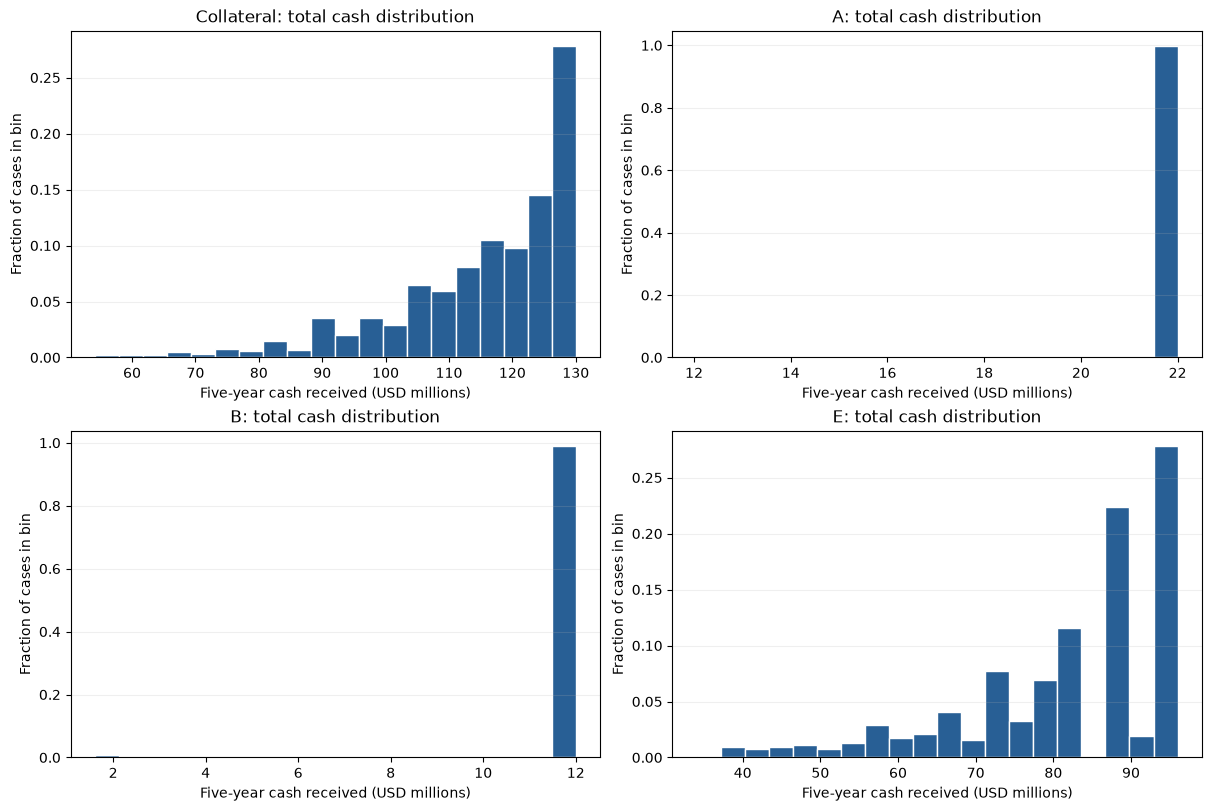

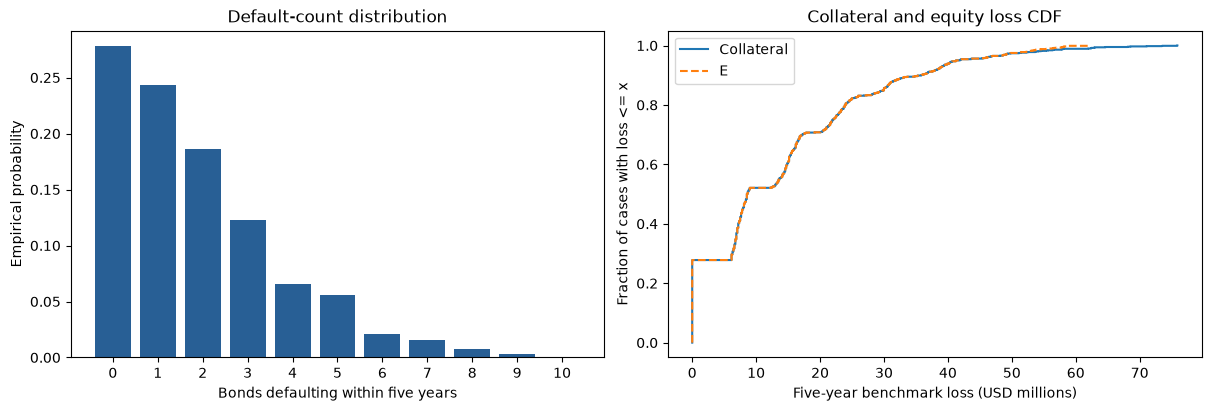

In [12]:
# Probability mass for the number of defaults in a case.
default_count_rows = []
counts = default_counts
for number_of_defaults in range(N_BONDS + 1):
    number_of_cases = int((counts == number_of_defaults).sum())
    default_count_rows.append({
        "defaults": number_of_defaults, "cases": number_of_cases,
        "probability": number_of_cases / N_SCENARIOS,
    })
default_distribution = pd.DataFrame(default_count_rows).set_index("defaults")
display(default_distribution)

# Exact empirical cash-flow distributions, stored for each class.
# Every distinct total has probability count / N_SCENARIOS.
cash_flow_distributions = {}
for name in cash_flow_tables:
    outcome_counts = total_cash_flows[name].value_counts().sort_index()
    distribution = pd.DataFrame({"cases": outcome_counts})
    distribution.index.name = "total_cash_USD"
    distribution["probability"] = distribution["cases"] / N_SCENARIOS
    distribution["cumulative_probability"] = distribution["probability"].cumsum()
    cash_flow_distributions[name] = distribution
    assert np.isclose(distribution["probability"].sum(), 1)
assert np.isclose(default_distribution["probability"].sum(), 1)

figure, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
for position in range(4):
    name = list(cash_flow_tables)[position]
    row = position // 2
    column = position % 2
    axis = axes[row, column]
    values_millions = total_cash_flows[name] / 1_000_000
    if values_millions.nunique() == 1:
        value = values_millions.iloc[0]
        axis.bar([value], [1.0], width=0.4, color="#218380")
        axis.set_xlim(value - 1, value + 1)
        axis.set_ylim(0, 1.1)
        axis.set_title(f"{name}: all cases pay {value:,.1f} million")
    else:
        weights = np.ones(N_SCENARIOS) / N_SCENARIOS
        axis.hist(values_millions, bins=20, weights=weights,
                  color="#285f95", edgecolor="white")
        axis.set_title(f"{name}: total cash distribution")
    axis.set_xlabel("Five-year cash received (USD millions)")
    axis.set_ylabel("Fraction of cases in bin")
    axis.grid(axis="y", alpha=0.2)
plt.show()

figure2, axes2 = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes2[0].bar(default_distribution.index, default_distribution["probability"], color="#285f95")
axes2[0].set_xticks(range(N_BONDS + 1))
axes2[0].set_xlabel("Bonds defaulting within five years")
axes2[0].set_ylabel("Empirical probability")
axes2[0].set_title("Default-count distribution")
for name in ["Collateral", "E"]:
    sorted_losses = np.sort(total_cash_losses[name].to_numpy()) / 1_000_000
    probabilities = np.arange(1, N_SCENARIOS + 1) / N_SCENARIOS
    # Include the initial zero-probability step.
    plot_losses = np.insert(sorted_losses, 0, sorted_losses[0])
    plot_probabilities = np.insert(probabilities, 0, 0)
    style = "-" if name == "Collateral" else "--"
    axes2[1].step(plot_losses, plot_probabilities, where="post", label=name, linestyle=style)
axes2[1].set_xlabel("Five-year benchmark loss (USD millions)")
axes2[1].set_ylabel("Fraction of cases with loss <= x")
axes2[1].set_title("Collateral and equity loss CDF")
axes2[1].legend()
plt.show()


### Quarterly cash-flow statistics
Summarize each payment date across cases. Negative quarterly benchmark losses indicate extra cash from early recovery; they are not negative five-year losses.

In [13]:
# Summarize each quarter separately across cases, not across time.
quarterly_rows = []
for name in cash_flow_tables:
    table = cash_flow_tables[name]
    for quarter_position in range(N_QUARTERS):
        quarter = quarter_position + 1
        payments = table.iloc[:, quarter_position]
        benchmark = benchmark_schedules[name][quarter_position]
        losses = benchmark - payments
        quarterly_rows.append({
            "class": name, "quarter": quarter, "time_years": payment_times[quarter_position],
            "mean_USD": payments.mean(), "std_USD": payments.std(ddof=1),
            "P5_USD": payments.quantile(0.05), "median_USD": payments.median(),
            "P95_USD": payments.quantile(0.95),
            "mean_loss_USD": losses.mean(), "loss_probability": (losses > 0.01).mean(),
        })
quarterly_statistics = pd.DataFrame(quarterly_rows)

def show_quarterly_statistics(class_name="Collateral"):
    rows = quarterly_statistics[quarterly_statistics["class"] == class_name]
    print(f"{class_name}: statistics across cases for each quarter (USD).")
    print("Quarterly loss is a signed benchmark difference: negative means receipts exceed that quarter\'s benchmark.")
    display(rows.drop(columns="class").set_index("quarter").round(4))

quarterly_statistics_viewer = widgets.interactive(
    show_quarterly_statistics,
    class_name=widgets.Dropdown(options=list(cash_flow_tables), description="Class:"),
)
display(quarterly_statistics_viewer)



interactive(children=(Dropdown(description='Class:', options=('Collateral', 'A', 'B', 'E'), value='Collateral'…

### Tranche payment shortfalls
For A and B, measure the probability of any missed scheduled payment and the average unpaid amount. Unpaid amounts do not carry forward.

In [14]:
shortfall_rows = []
for position, name in enumerate(["A", "B"]):
    shortfalls = tranche_shortfalls[:, :, position]
    totals = shortfalls.sum(axis=1)
    affected = totals > 0.01
    shortfall_rows.append({
        "class": name,
        "cases_with_shortfall": int(affected.sum()),
        "probability_any_shortfall": affected.mean(),
        "mean_shortfall_USD": totals.mean(),
        "mean_given_shortfall_USD": totals[affected].mean() if affected.any() else np.nan,
        "max_shortfall_USD": totals.max(),
    })
    np.testing.assert_allclose(totals, total_cash_losses[name])
shortfall_statistics = pd.DataFrame(shortfall_rows).set_index("class")
display(shortfall_statistics.round(4))

,cases_with_shortfall,probability_any_shortfall,mean_shortfall_USD,mean_given_shortfall_USD,max_shortfall_USD
class,,,,,
A,3,0.003,29850.0,9.950000e+06,9950000.0
B,11,0.011,97850.0,8.895455e+06,10400000.0


### Collateral mean check
Compare simulated quarterly means with the theoretical means under lump-sum recovery. Finite simulation and moment matching can cause differences.

In [15]:
survival = np.exp(-hazard_rate * payment_times)
previous_survival = np.exp(-hazard_rate * (payment_times - DT))
theoretical_collateral_mean = N_BONDS * (
    QUARTERLY_COUPON * survival + RECOVERY * (previous_survival - survival)
)
theoretical_collateral_mean[-1] += N_BONDS * FACE_VALUE * survival[-1]
mean_cash_flow_check = pd.DataFrame({
    "theoretical_mean_USD": theoretical_collateral_mean,
    "simulated_mean_USD": collateral_cash_flows.mean(axis=0),
}, index=quarter_labels)
mean_cash_flow_check["difference_USD"] = (
    mean_cash_flow_check["simulated_mean_USD"] - mean_cash_flow_check["theoretical_mean_USD"]
)
display(mean_cash_flow_check.round(2))
print(f"Theoretical five-year mean: {theoretical_collateral_mean.sum():,.2f} USD")
print(f"Simulated five-year mean: {total_cash_flows['Collateral'].mean():,.2f} USD")

,theoretical_mean_USD,simulated_mean_USD,difference_USD
Q1,1890913.57,1896550.0,5636.43
Q2,1871713.99,1888800.0,17086.01
Q3,1852709.36,1861500.0,8790.64
Q4,1833897.69,1919350.0,85452.31
Q5,1815277.03,1835750.0,20472.97
Q6,1796845.43,1820150.0,23304.57
Q7,1778600.98,1712150.0,-66450.98
Q8,1760541.78,1723250.0,-37291.78
Q9,1742665.95,1687250.0,-55415.95
Q10,1724971.61,1682950.0,-42021.61


Theoretical five-year mean: 115,920,572.04 USD
Simulated five-year mean: 115,832,350.00 USD


## 7. Numerical sensitivities
Change one parameter at a time using the same 1,000 fixed draws. All other inputs and the lump-sum recovery/bullet waterfall remain fixed. Correlation refers to full default times and is recalibrated for each target; amounts are undiscounted USD.

In [16]:
# Restore the existing moment-matched draws to ORIGINAL case order.
# Keep this order in every sensitivity; do not align scenarios by default rank.
fixed_normals = np.empty_like(independent_normals)
fixed_normals[scenario_order] = independent_normals
fixed_normals.setflags(write=False)
original_order = np.argsort(original_case_ids)
rho_cache = {TARGET_DEFAULT_TIME_CORRELATION: LATENT_RHO}

def calibrate_sensitivity_correlation(target):
    if not 0 <= target < 1:
        raise ValueError("Use a default-time correlation from 0 inclusive to 1 exclusive.")
    if target not in rho_cache:
        if target == 0:
            rho_cache[target] = 0.0
        else:
            rho_cache[target] = brentq(
                lambda rho: implied_default_time_correlation(rho) - target,
                0.0, 1.0, xtol=1e-12,
            )
    rho = rho_cache[target]
    np.testing.assert_allclose(implied_default_time_correlation(rho, 80), target, atol=1e-9, rtol=0)
    return rho

def run_sensitivity(pd_value, lgd_value, correlation):
    if not 0 < pd_value < 1 or not 0 <= lgd_value <= 1:
        raise ValueError("PD must be between 0 and 1; LGD must be between 0 and 1 inclusive.")
    rho = calibrate_sensitivity_correlation(correlation)
    matrix = np.full((N_BONDS, N_BONDS), rho)
    np.fill_diagonal(matrix, 1.0)
    scores = fixed_normals @ np.linalg.cholesky(matrix).T
    percentiles = np.clip(ndtr(scores), np.finfo(float).tiny, np.nextafter(1.0, 0.0))
    hazard = -np.log1p(-pd_value)
    times = -np.log1p(-percentiles) / hazard

    # Same recovery convention as the base model: one payment in the default quarter.
    cash = np.zeros((N_SCENARIOS, N_QUARTERS))
    recovery = FACE_VALUE * (1 - lgd_value)
    for quarter_position, payment_time in enumerate(payment_times):
        alive = times > payment_time
        new_defaults = (times > payment_time - DT) & (times <= payment_time)
        cash[:, quarter_position] = (
            QUARTERLY_COUPON * alive.sum(axis=1)
            + recovery * new_defaults.sum(axis=1)
        )
        if quarter_position == N_QUARTERS - 1:
            cash[:, quarter_position] += FACE_VALUE * alive.sum(axis=1)
    allocations = apply_waterfall(cash, schedule_values)
    np.testing.assert_allclose(allocations.sum(axis=2), cash, atol=1e-8, rtol=0)
    shortfalls = schedule_values[None, :, :] - allocations[:, :, :2]
    assert (shortfalls >= -1e-8).all()
    for position in range(2):
        unpaid = shortfalls[:, :, position] > 0.01
        assert (allocations[:, :, position + 1:][unpaid] == 0).all()

    totals = {"Collateral": cash.sum(axis=1)}
    for position, name in enumerate(class_names):
        totals[name] = allocations[:, :, position].sum(axis=1)
    rows = []
    for name, receipts in totals.items():
        loss = benchmark_schedules[name].sum() - receipts
        rows.append({
            "class": name, "PD": pd_value, "LGD": lgd_value,
            "default_time_correlation": correlation, "normal_correlation": rho,
            "mean_receipts_USD": receipts.mean(), "std_USD": receipts.std(ddof=1),
            "P5_receipts_USD": np.quantile(receipts, 0.05),
            "mean_loss_USD": loss.mean(), "loss_probability": (loss > 0.01).mean(),
            "loss_VaR95_USD": np.quantile(loss, 0.95),
            "loss_ES95_USD": expected_shortfall(loss),
        })
    return pd.DataFrame(rows), cash, allocations

baseline_sensitivity, base_check_cash, base_check_allocations = run_sensitivity(
    ANNUAL_DEFAULT_PROBABILITY, LGD, TARGET_DEFAULT_TIME_CORRELATION
)
np.testing.assert_allclose(base_check_cash, collateral_cash_flows[original_order], atol=1e-8, rtol=0)
np.testing.assert_allclose(base_check_allocations, tranche_cash_flows[original_order], atol=1e-8, rtol=0)
np.testing.assert_allclose(baseline_sensitivity["mean_receipts_USD"], total_statistics.loc[["Collateral", "A", "B", "E"], "mean_USD"])
print("Sensitivity engine reproduces the base model case by case.")

sensitivity_grids = {
    "Annual default probability": [0.02, 0.04, 0.06, 0.08],
    "LGD": [0.40, 0.60, 0.80, 1.00],
    "Default-time correlation": [0.00, 0.20, 0.40, 0.60],
}
sensitivity_tables = {}
for parameter, values in sensitivity_grids.items():
    results = []
    for value in values:
        pd_value = ANNUAL_DEFAULT_PROBABILITY
        lgd_value = LGD
        correlation = TARGET_DEFAULT_TIME_CORRELATION
        if parameter == "Annual default probability":
            pd_value = value
        elif parameter == "LGD":
            lgd_value = value
        else:
            correlation = value
        result, _, _ = run_sensitivity(pd_value, lgd_value, correlation)
        result.insert(0, "parameter_value", value)
        for name in class_names + ["Collateral"]:
            selected = result["class"] == name
            result.loc[selected, "change_in_mean_USD"] = (
                result.loc[selected, "mean_receipts_USD"] - total_statistics.loc[name, "mean_USD"]
            )
        results.append(result)
    sensitivity_tables[parameter] = pd.concat(results, ignore_index=True)

def show_sensitivity(parameter):
    table = sensitivity_tables[parameter]
    columns = ["parameter_value", "class", "mean_receipts_USD", "change_in_mean_USD",
               "std_USD", "P5_receipts_USD", "mean_loss_USD", "loss_probability",
               "loss_VaR95_USD", "loss_ES95_USD"]
    print("Amounts: USD. Loss probability is payment-shortfall probability for A and B.")
    display(table[columns].set_index(["parameter_value", "class"]).round(4))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
    metrics = ["mean_receipts_USD", "loss_ES95_USD", "loss_probability"]
    titles = ["Expected five-year receipts", "95% expected shortfall", "Probability of cash-flow loss"]
    for position, metric in enumerate(metrics):
        for name in ["Collateral", "A", "B", "E"]:
            selected = table[table["class"] == name]
            scale = 100 if metric == "loss_probability" else 1 / 1_000_000
            axes[position].plot(selected["parameter_value"] * 100, selected[metric] * scale,
                                marker="o", label=name)
        axes[position].set_xlabel(parameter + " (%)")
        axes[position].set_ylabel("Percent of cases" if metric == "loss_probability" else "USD millions")
        axes[position].set_title(titles[position])
        axes[position].grid(alpha=0.2)
    axes[0].legend()
    plt.show()
print("Completed 12 one-parameter runs with common draws and fixed original case IDs.")

Sensitivity engine reproduces the base model case by case.
Completed 12 one-parameter runs with common draws and fixed original case IDs.


### Annual default probability sensitivity
Compare 2%, 4% (base), 6%, and 8% annual default probability, holding LGD and default-time correlation fixed.

Amounts: USD. Loss probability is payment-shortfall probability for A and B.


mean_receipts_USD  change_in_mean_USD  \
parameter_value class                                               
0.02            Collateral        122672650.0           6840300.0   
                A                  22000000.0             29850.0   
                B                  11980200.0             78050.0   
                E                  88692450.0           6732400.0   
0.04            Collateral        115832350.0                 0.0   
                A                  21970150.0                 0.0   
                B                  11902150.0                 0.0   
                E                  81960050.0                 0.0   
0.06            Collateral        109585000.0          -6247350.0   
                A                  21874550.0            -95600.0   
                B                  11726700.0           -175450.0   
                E                  75983750.0          -5976300.0   
0.08            Collateral        103799500.0         -12032850.0   
                A                  21668000.0           -302150.0   
                B                  11499650.0           -402500.0   
                E                  70631850.0         -11328200.0   

                                 std_USD  P5_receipts_USD  mean_loss_USD  \
parameter_value class                                                      
0.02            Collateral  1.008664e+07      101477500.0      7327350.0   
                A           0.000000e+00       22000000.0            0.0   
                B           4.425198e+05       12000000.0        19800.0   
                E           9.984369e+06       67477500.0      7307550.0   
0.04            Collateral  1.439774e+07       88720000.0     14167650.0   
                A           5.444381e+05       22000000.0        29850.0   
                B           9.481545e+05       12000000.0        97850.0   
                E           1.397209e+07       54720000.0     14039950.0   
0.06            Collateral  1.683787e+07       76300000.0     20415000.0   
                A           1.151969e+06       22000000.0       125450.0   
                B           1.621270e+06       12000000.0       273300.0   
                E           1.582649e+07       44677500.0     20016250.0   
0.08            Collateral  1.841604e+07       69812500.0     26200500.0   
                A           1.965567e+06       22000000.0       332000.0   
                B           2.182670e+06        9900000.0       500350.0   
                E           1.667130e+07       41392500.0     25368150.0   

                            loss_probability  loss_VaR95_USD  loss_ES95_USD  
parameter_value class                                                        
0.02            Collateral             0.503      28522500.0     37377000.0  
                A                      0.000             0.0            0.0  
                B                      0.002             0.0       396000.0  
                E                      0.503      28522500.0     36981000.0  
0.04            Collateral             0.722      41280000.0     53343000.0  
                A                      0.003             0.0       597000.0  
                B                      0.011             0.0      1957000.0  
                E                      0.722      41280000.0     50789000.0  
0.06            Collateral             0.837      53700000.0     62961000.0  
                A                      0.014             0.0      2509000.0  
                B                      0.028             0.0      5466000.0  
                E                      0.837      51322500.0     55492000.0  
0.08            Collateral             0.910      60187500.0     70101000.0  
                A                      0.031             0.0      6640000.0  
                B                      0.051       2100000.0      9969000.0  
                E                      0.910      54607500.0     56840000.0

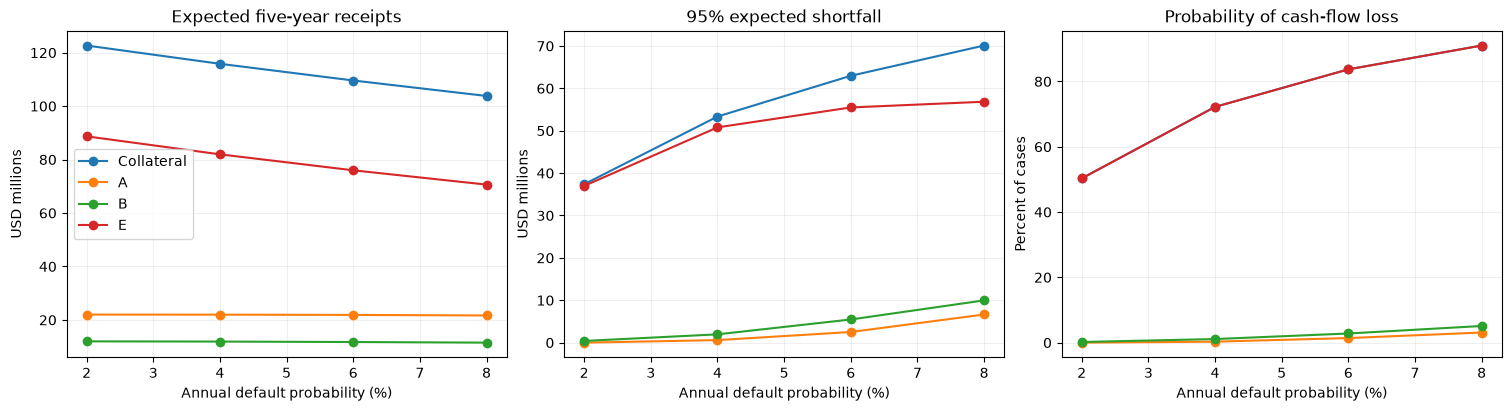

In [17]:
show_sensitivity("Annual default probability")

### LGD sensitivity
Compare 40%, 60% (base), 80%, and 100% LGD. Higher LGD reduces the recovery paid in the default quarter.

Amounts: USD. Loss probability is payment-shortfall probability for A and B.


mean_receipts_USD  change_in_mean_USD  \
parameter_value class                                               
0.4             Collateral        119546350.0           3714000.0   
                A                  21970150.0                 0.0   
                B                  11908150.0              6000.0   
                E                  85668050.0           3708000.0   
0.6             Collateral        115832350.0                 0.0   
                A                  21970150.0                 0.0   
                B                  11902150.0                 0.0   
                E                  81960050.0                 0.0   
0.8             Collateral        112118350.0          -3714000.0   
                A                  21970150.0                 0.0   
                B                  11896150.0             -6000.0   
                E                  78252050.0          -3708000.0   
1.0             Collateral        108404350.0          -7428000.0   
                A                  21970150.0                 0.0   
                B                  11890000.0            -12150.0   
                E                  74544200.0          -7415850.0   

                                 std_USD  P5_receipts_USD  mean_loss_USD  \
parameter_value class                                                      
0.4             Collateral  1.072966e+07       98730000.0     10453650.0   
                A           5.444381e+05       22000000.0        29850.0   
                B           9.172117e+05       12000000.0        91850.0   
                E           1.033400e+07       64730000.0     10331950.0   
0.6             Collateral  1.439774e+07       88720000.0     14167650.0   
                A           5.444381e+05       22000000.0        29850.0   
                B           9.481545e+05       12000000.0        97850.0   
                E           1.397209e+07       54720000.0     14039950.0   
0.8             Collateral  1.807384e+07       78000000.0     17881650.0   
                A           5.444381e+05       22000000.0        29850.0   
                B           9.902870e+05       12000000.0       103850.0   
                E           1.762315e+07       44000000.0     17747950.0   
1.0             Collateral  2.175390e+07       68000000.0     21595650.0   
                A           5.444381e+05       22000000.0        29850.0   
                B           1.043712e+06       12000000.0       110000.0   
                E           2.128003e+07       34000000.0     21455800.0   

                            loss_probability  loss_VaR95_USD  loss_ES95_USD  
parameter_value class                                                        
0.4             Collateral             0.722      31270000.0     39863000.0  
                A                      0.003             0.0       597000.0  
                B                      0.011             0.0      1837000.0  
                E                      0.722      31270000.0     37429000.0  
0.6             Collateral             0.722      41280000.0     53343000.0  
                A                      0.003             0.0       597000.0  
                B                      0.011             0.0      1957000.0  
                E                      0.722      41280000.0     50789000.0  
0.8             Collateral             0.722      52000000.0     66858000.0  
                A                      0.003             0.0       597000.0  
                B                      0.011             0.0      2077000.0  
                E                      0.722      52000000.0     64184000.0  
1.0             Collateral             0.722      62000000.0     80418000.0  
                A                      0.003             0.0       597000.0  
                B                      0.011             0.0      2200000.0  
                E                      0.722      62000000.0     77621000.0

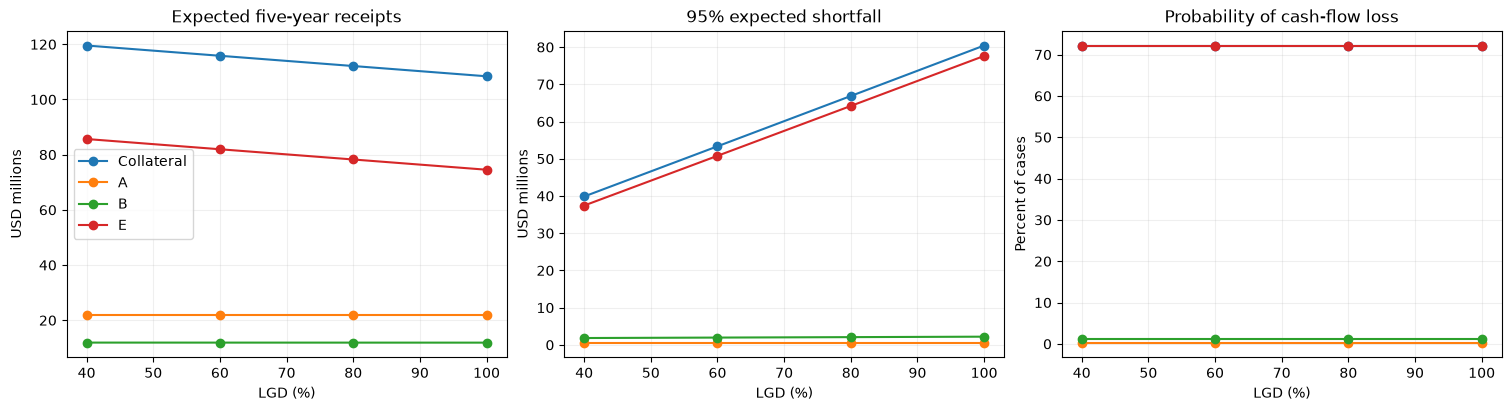

In [18]:
show_sensitivity("LGD")

### Default-time correlation sensitivity
Compare 0%, 20% (base), 40%, and 60% correlation after recalibrating normal correlation. Theoretical mean collateral receipts are unchanged; simulated means may fluctuate. Tranche risks and tail losses can change.

Amounts: USD. Loss probability is payment-shortfall probability for A and B.


mean_receipts_USD  change_in_mean_USD  \
parameter_value class                                               
0.0             Collateral        116059600.0            227250.0   
                A                  22000000.0             29850.0   
                B                  12000000.0             97850.0   
                E                  82059600.0             99550.0   
0.2             Collateral        115832350.0                 0.0   
                A                  21970150.0                 0.0   
                B                  11902150.0                 0.0   
                E                  81960050.0                 0.0   
0.4             Collateral        115958650.0            126300.0   
                A                  21743450.0           -226700.0   
                B                  11685900.0           -216250.0   
                E                  82529300.0            569250.0   
0.6             Collateral        115953550.0            121200.0   
                A                  21340750.0           -629400.0   
                B                  11339550.0           -562600.0   
                E                  83273250.0           1313200.0   

                                 std_USD  P5_receipts_USD  mean_loss_USD  \
parameter_value class                                                      
0.0             Collateral  9.854987e+06       98650000.0     13940400.0   
                A           0.000000e+00       22000000.0            0.0   
                B           0.000000e+00       12000000.0            0.0   
                E           9.854987e+06       64650000.0     13940400.0   
0.2             Collateral  1.439774e+07       88720000.0     14167650.0   
                A           5.444381e+05       22000000.0        29850.0   
                B           9.481545e+05       12000000.0        97850.0   
                E           1.397209e+07       54720000.0     14039950.0   
0.4             Collateral  1.802424e+07       77492500.0     14041350.0   
                A           1.911571e+06       22000000.0       256550.0   
                B           1.763439e+06       12000000.0       314100.0   
                E           1.634757e+07       45142500.0     13470700.0   
0.6             Collateral  2.116021e+07       65920000.0     14046450.0   
                A           3.311613e+06       22000000.0       659250.0   
                B           2.513499e+06        2100000.0       660450.0   
                E           1.767093e+07       43337500.0     12726750.0   

                            loss_probability  loss_VaR95_USD  loss_ES95_USD  
parameter_value class                                                        
0.0             Collateral             0.851      31350000.0     37377000.0  
                A                      0.000             0.0            0.0  
                B                      0.000             0.0            0.0  
                E                      0.851      31350000.0     37377000.0  
0.2             Collateral             0.722      41280000.0     53343000.0  
                A                      0.003             0.0       597000.0  
                B                      0.011             0.0      1957000.0  
                E                      0.722      41280000.0     50789000.0  
0.4             Collateral             0.604      52507500.0     65913000.0  
                A                      0.021             0.0      5131000.0  
                B                      0.031             0.0      6282000.0  
                E                      0.604      50857500.0     54833000.0  
0.6             Collateral             0.503      64080000.0     76521000.0  
                A                      0.043             0.0     13185000.0  
                B                      0.066       9900000.0     10441000.0  
                E                      0.503      52662500.0     55485000.0

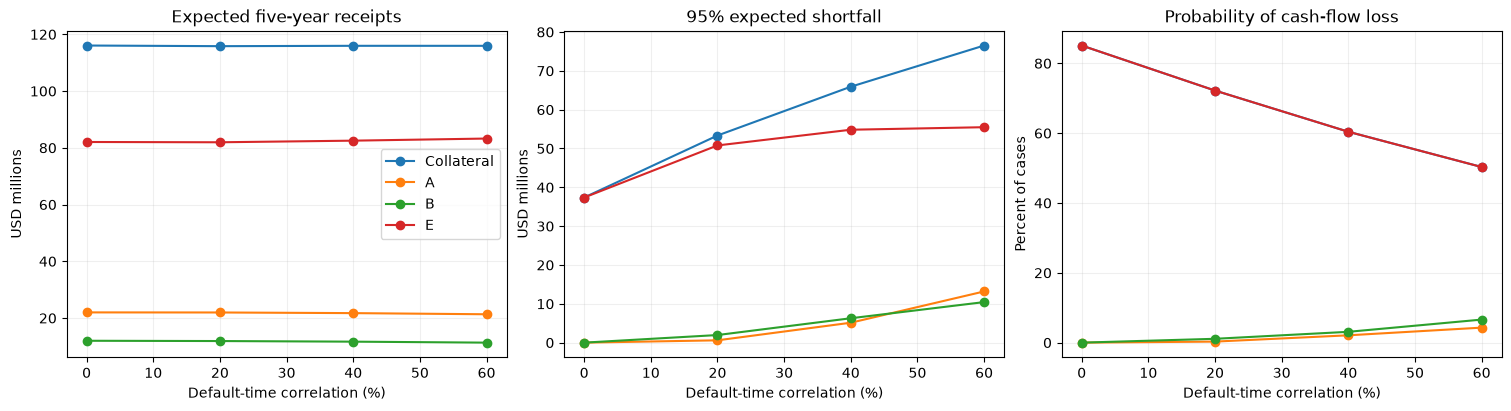

,default_time_correlation,normal_correlation
0,0.0,0.000000
1,0.2,0.233235
2,0.4,0.446290
3,0.6,0.643302


In [19]:
show_sensitivity("Default-time correlation")
display(sensitivity_tables["Default-time correlation"][["default_time_correlation", "normal_correlation"]].drop_duplicates().reset_index(drop=True))